# Representation Learning with t-SNE and UMAP: Visualizing Hidden Patient Structures

### Question
> Which representation learning method best reveals the hidden structure of thyroid cancer patients? Does nonlinear dimensionality reduction (t-SNE or UMAP) reveal more meaningful patient groups than PCA alone or the original feature space?

### Datasets: Two preprocessed feature sets will be investigated.

- Feature Set A: Baseline clinicopathologic characteristics.
- Feature Set B: Baseline clinicopathologic characteristics together with treatment response.
- PCA A 80: Feature Set A after PCA with an 80% explained variance threshold
- PCA B 80: Feature Set B after PCA with an 80% explained variance threshold

### - Import Libraries

In [5]:
# ==========================================================
# Path Setup
# ==========================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "Notebooks"))
DATA_DIR = PROJECT_ROOT / "Data"

# ==========================================================
# Data Handling
# ==========================================================

import pandas as pd
import numpy as np

# ==========================================================
# Visualization
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# ==========================================================
# Preprocessing
# ==========================================================

from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

# ==========================================================
# Dimensionality Reduction
# ==========================================================

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# ==========================================================
# Clustering Algorithms
# ==========================================================

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)

from sklearn.mixture import GaussianMixture

# ==========================================================
# Evaluation Metrics
# ==========================================================

from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# ==========================================================
# Utilities
# ==========================================================

from kneed import KneeLocator
import joblib

from utils import *

### - Load datasets

In [6]:
X_A = pd.read_csv(DATA_DIR / "feature_set_A.csv")
X_B = pd.read_csv(DATA_DIR / "feature_set_B.csv")
X_A_80 = pd.read_csv(DATA_DIR / "PCA_A_80.csv")
X_B_80 = pd.read_csv(DATA_DIR / "PCA_B_80.csv")

# External validation only
y = pd.read_csv(DATA_DIR / "recurred.csv")

### 1) Build the embeddings

In [8]:
# ----------------------------------------------------------
# Build t-SNE & UMAP Embeddings
# ----------------------------------------------------------

def build_embeddings(
    X,
    random_state=42,
    pca_components=0.80
):
    """
    Generate t-SNE and UMAP embeddings.

    Parameters
    ----------
    X : pd.DataFrame
        Original feature matrix.

    pca_components : float or int
        PCA explained variance ratio or fixed number of components.

    Returns
    -------
    embeddings : dict
    """

    X_input = X.copy()

    # -----------------------------
    # t-SNE
    # -----------------------------

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=random_state
    )

    X_tsne = tsne.fit_transform(X_input)

    # -----------------------------
    # UMAP
    # -----------------------------

    umap_model = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.10,
        metric="euclidean",
        random_state=random_state
    )

    X_umap = umap_model.fit_transform(X_input)

    return {
        "tSNE": X_tsne,
        "UMAP": X_umap
    }

In [14]:
# ----------------------------------------------------------
# Apply embeddings to every dataset
# ----------------------------------------------------------

def apply_embeddings(X_A, X_B, X_A_80, X_B_80):

    embeddings = {
        "A_Original": build_embeddings(X_A),
        "B_Original": build_embeddings(X_B),
        "A_PCA_80": build_embeddings(X_A_80),
        "B_PCA_80": build_embeddings(X_B_80),
    }

    return embeddings

In [ ]:
embeddings = apply_embeddings(X_A, X_B, X_A_80, X_B_80)

### 2) Visualize all embeddings

In [ ]:

def plot_embeddings_comparison(embeddings, y=None, title_prefix=""):
    """Plots t-SNE and UMAP side-by-side for Feature Sets A and B in a 2x2 grid."""

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))

    feature_keys = list(embeddings.keys())  # Expected: ['A', 'B']
    methods = ["tSNE", "UMAP"]

    if y is not None:
        y_flat = y.squeeze()
        classes = np.unique(y_flat)
        cmap = plt.colormaps["coolwarm"].resampled(len(classes))

    for row_idx, feature_name in enumerate(feature_keys):
        feature_dict = embeddings[feature_name]

        for col_idx, method in enumerate(methods):
            ax = axes[row_idx, col_idx]

            if method not in feature_dict:
                ax.set_visible(False)
                continue

            emb_data = feature_dict[method]

            if y is None:
                ax.scatter(emb_data[:, 0], emb_data[:, 1], s=20, alpha=0.8)
            else:
                for idx, cls in enumerate(classes):
                    mask = y_flat == cls
                    ax.scatter(
                        emb_data[mask, 0],
                        emb_data[mask, 1],
                        color=cmap(idx),
                        label=f"Class {cls}",
                        s=20,
                        alpha=0.85,
                    )

            ax.set_title(f"Set {feature_name} — {method}", fontsize=11)
            ax.set_xlabel("Component 1", fontsize=9)
            ax.set_ylabel("Component 2", fontsize=9)
            ax.grid(True, alpha=0.3)

    if title_prefix:
        fig.suptitle(title_prefix, fontsize=13, fontweight="bold")

    if y is not None:
        handles, labels = axes[0, 0].get_legend_handles_labels()

        axes[1, 1].legend(
            handles,
            labels,
            title="Target Class",
            loc="lower right",
            bbox_to_anchor=(1, 0.1),
            frameon=True,
        )

    plt.tight_layout()
    plt.show()

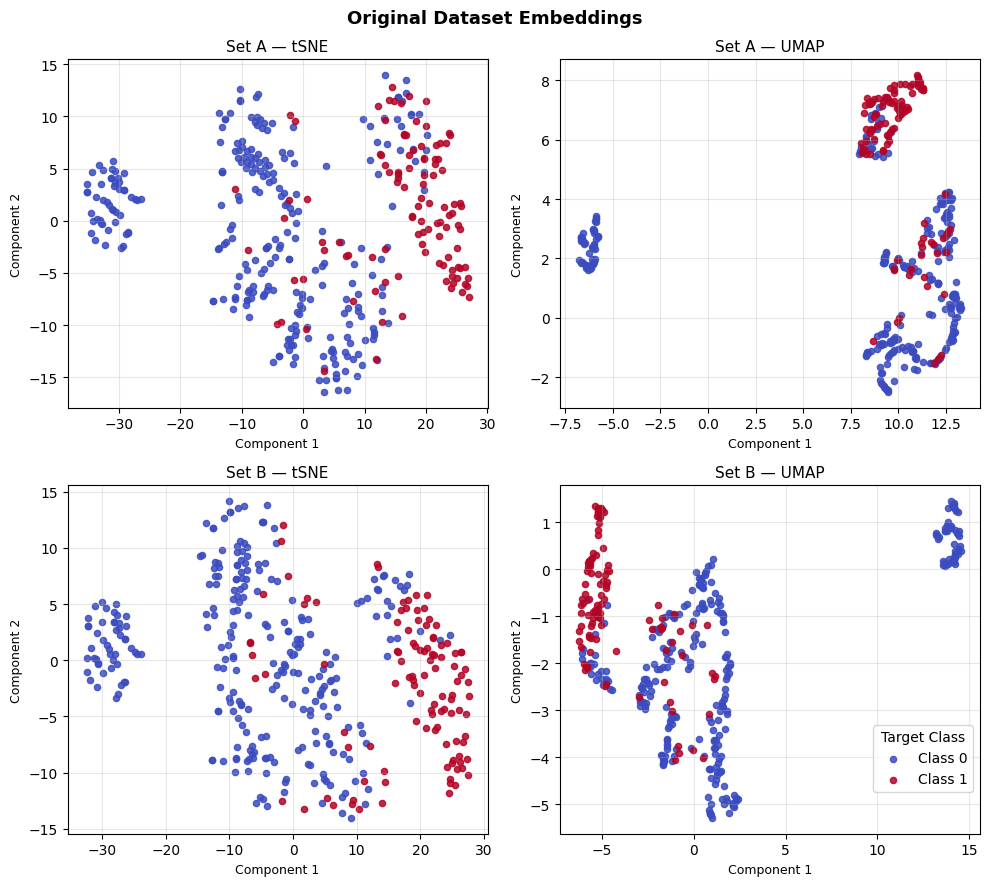

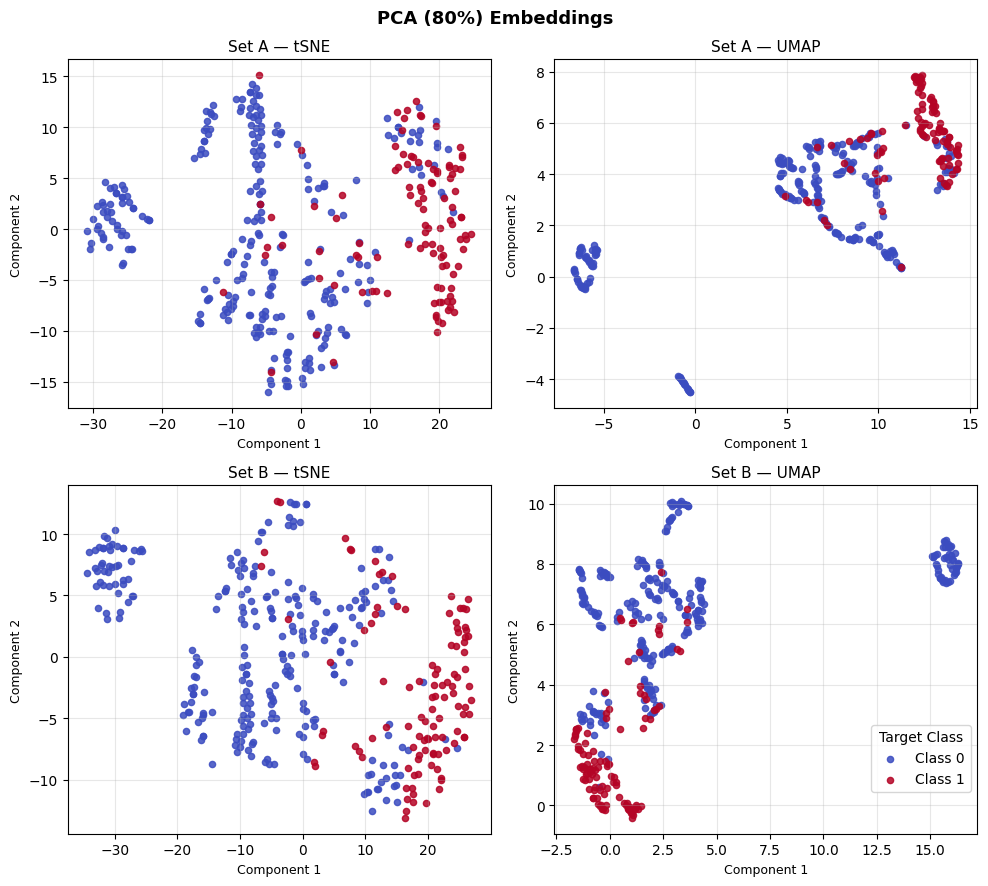

In [40]:
org_embeddings = {
    "A": embeddings["A_Original"],
    "B": embeddings["B_Original"],
}

pca_embeddings = {
    "A": embeddings["A_PCA_80"],
    "B": embeddings["B_PCA_80"],
}

# 1. Original Dataset Comparison Figure
plot_embeddings_comparison(
    org_embeddings, y, title_prefix="Original Dataset Embeddings"
)

# 2. PCA Dataset Comparison Figure
plot_embeddings_comparison(
    pca_embeddings, y, title_prefix="PCA (80%) Embeddings"
)

**Interpretation:** The t-SNE and UMAP visualizations reveal meaningful latent organization within the thyroid cancer dataset. Both methods identify patient neighborhoods with partial separation between recurrent and non-recurrent cases despite never using the recurrence labels during embedding. UMAP produces more compact and better-separated clusters than t-SNE, particularly for Feature Set B, suggesting superior preservation of the underlying data manifold. Applying PCA prior to nonlinear embedding maintains—and in some cases slightly improves—the visual separability while reducing dimensionality, indicating that most clinically relevant information is retained within the first principal components. These visual findings are consistent with the internal clustering metrics obtained in the previous notebook, further supporting the effectiveness of PCA as a preprocessing step.

# Observation

PCA preserved the global structure of the thyroid cancer dataset while reducing dimensionality efficiently. Applying PCA before nonlinear embedding slightly reduced noise and produced cleaner visualizations. t-SNE generated compact local neighborhoods but showed little information about the global arrangement of clusters. UMAP provided the clearest separation between recurrent and non-recurrent patients while preserving more of the global organization than t-SNE. Overall, PCA preprocessing had only a modest effect on the visual appearance, indicating that the original feature sets already captured the dominant variance effectively.

# Conclusion

This notebook demonstrated three complementary dimensionality reduction techniques. PCA was shown to be an efficient linear method suitable for compression and preprocessing, whereas t-SNE and UMAP provided nonlinear embeddings primarily intended for visualization. The experiments showed that nonlinear embeddings can reveal clinically meaningful structures that are difficult to observe in the original feature space, while PCA preprocessing can slightly improve embedding quality by removing noise. These methods should therefore be regarded as exploratory visualization tools rather than clustering algorithms or predictive models.